# Mini Project – Analisis Pipeline GC Content Sekuens Genom
---

**Deskripsi Proyek:**  
Analisis komparatif GC Content sekuens genom pada tiga organisme:
- *Methanocaldococcus jannaschii*
- *Escherichia coli*
- *Psychrobacter arcticus*

**Pipeline:**
1. Membaca file FASTA dari NCBI
2. Menyimpan data dalam List
3. Menghitung frekuensi nukleotida menggunakan Dictionary
4. Mengurutkan sekuens berdasarkan GC Content
5. Menampilkan 3 sekuens dengan GC Content tertinggi
6. Membuat visualisasi grafik
7. Mengekspor hasil ke file CSV
8. Membuat ringkasan interpretasi hasil


---
##  0. Import Library


In [1]:
# Import Library & Konfigurasi Global
# Install Biopython if not already installed
!pip install biopython
# Library standar
import os
import csv
import time
# Library bioinformatika
from Bio import SeqIO, Entrez
from Bio.SeqUtils import gc_fraction   # Biopython >= 1.80
# Library visualisasi & data
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Konfigurasi Entrez (wajib diisi untuk akses NCBI)
Entrez.email = "isnainitiana@apps.ipb.ac.id"

# Konfigurasi tampilan
plt.rcParams.update({
    'font.family'  : 'DejaVu Sans',
    'font.size'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# Warna per spesies
SPECIES_COLOR = {
    'Methanocaldococcus jannaschii' : '#2E86AB',   # biru
    'Escherichia coli'              : '#E84855',   # merah
    'Psychrobacter arcticus'        : '#3BB273',   # hijau
}

# Path output
FASTA_FILE  = 'genome_sequences_3organisms.fasta'
OUTPUT_CSV  = 'hasil_gc_content.csv'
OUTPUT_DIR  = 'output_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 11.8 MB/s eta 0:00:00


---
## 1. Akuisisi Data – Unduh Sekuens FASTA dari NCBI

Sekuens genom yang digunakan:

| Spesies | Accession Number | Keterangan |
|---|---|---|
| *Methanocaldococcus jannaschii* | `NC_000909.1` | Sekuens genom *Methanocaldococcus jannaschii* |
| *Escherichia coli* | `NC_000913.3` | Sekuens genom *Escherichia coli* |
| *Psychrobacter arcticus* | `NC_007204.1` | Sekuens genom *Psychrobacter arcticus* |

> ⚠️ Jika file FASTA sudah tersedia secara lokal, lewati sel ini.


In [2]:
ACCESSION_MAP = {
    'NC_000909.1' : 'Methanocaldococcus jannaschii',
    'NC_000913.3' : 'Escherichia coli',
    'NC_007204.1' : 'Psychrobacter arcticus',}

def download_fasta(accession_map: dict, output_file: str) -> None:
    records_all = []

    for acc, species in accession_map.items():
        print(f'Mengunduh {acc} ({species}) ...', end=' ')
        try:
            handle  = Entrez.efetch(
                db       = 'nucleotide',
                id       = acc,
                rettype  = 'fasta',
                retmode  = 'text'
            )
            record  = SeqIO.read(handle, 'fasta')
            handle.close()

            # Beri label spesies pada description
            record.description = f'{record.description} | {species}'
            records_all.append(record)
            print('✅')
            time.sleep(0.5)   # Patuhi rate-limit NCBI
        except Exception as err:
            print(f'❌  Gagal: {err}')

    # Simpan semua record ke satu file FASTA
    with open(output_file, 'w') as f_out:
        SeqIO.write(records_all, f_out, 'fasta')
    print(f'\n💾 {len(records_all)} sekuens disimpan ke "{output_file}"')


# Jalankan unduhan jika file belum ada
if not os.path.exists(FASTA_FILE):
    print(' Menghubungi server NCBI ...')
    download_fasta(ACCESSION_MAP, FASTA_FILE)
else:
    print(f'📂 File "{FASTA_FILE}" sudah tersedia. Unduhan dilewati.')

 Menghubungi server NCBI ...
Mengunduh NC_000909.1 (Methanocaldococcus jannaschii) ... ✅
Mengunduh NC_000913.3 (Escherichia coli) ... ✅
Mengunduh NC_007204.1 (Psychrobacter arcticus) ... ✅

💾 3 sekuens disimpan ke "genome_sequences_3organisms.fasta"


---
## 2. Membaca File FASTA & Menyimpan Data dalam List


In [3]:
# Membaca FASTA & Menyimpan dalam List
# Mapping accession> nama spesies untuk lookup saat parsing
ACC_TO_SPECIES = {
    'NC_000909.1' : 'Methanocaldococcus jannaschii',
    'NC_000913.3' : 'Escherichia coli',
    'NC_007204.1' : 'Psychrobacter arcticus',}

def parse_species(record_id: str, record_desc: str) -> str:
    for acc, sp in ACC_TO_SPECIES.items():
        if acc in record_id or acc in record_desc:
            return sp

    # Fallback: cari nama genus-spesies dalam deskripsi
    desc_lower = record_desc.lower()
    if 'methanocaldococcus jannaschii' in desc_lower: return 'Methanocaldococcus jannaschii'
    if 'escherichia coli'              in desc_lower: return 'Escherichia coli'
    if 'psychrobacter arcticus'        in desc_lower: return 'Psychrobacter arcticus'
    return 'Unknown'


# Membaca FASTA ke dalam List of Dict
sequence_list = []
with open(FASTA_FILE, 'r') as fasta_handle:
    for record in SeqIO.parse(fasta_handle, 'fasta'):
        species = parse_species(record.id, record.description)
        entry = {
            'id'         : record.id,
            'description': record.description,
            'species'    : species,
            'sequence'   : str(record.seq).upper(),
            'length_bp'  : len(record.seq),
        }
        sequence_list.append(entry)

# Ringkasan
print(f'📋 Total sekuens terbaca : {len(sequence_list)}\n')
print(f'{"No":<4} {"Accession":<20} {"Spesies":<35} {"Panjang (bp)":>12}')
print('─' * 78)

for i, seq in enumerate(sequence_list, 1):
    print(f'{i:<4} {seq["id"]:<20} {seq["species"]:<35} {seq["length_bp"]:>12,}')

📋 Total sekuens terbaca : 3

No   Accession            Spesies                             Panjang (bp)
──────────────────────────────────────────────────────────────────────────────
1    NC_000909.1          Methanocaldococcus jannaschii          1,664,970
2    NC_000913.3          Escherichia coli                       4,641,652
3    NC_007204.1          Psychrobacter arcticus                 2,650,701


---
## 3. Menghitung Frekuensi Nukleotida Menggunakan Dictionary


In [4]:
# Hitung Frekuensi Nukleotida, GC Content, dan Ranking
def analisis_komposisi_nukleotida(sequence: str) -> dict:
    bases = ["A", "T", "G", "C", "N"]
    freq_count = {base: 0 for base in bases}
    for nucleotide in sequence:
        if nucleotide in freq_count:
            freq_count[nucleotide] += 1
        else:
            freq_count["N"] += 1
    valid_bp = freq_count["A"] + freq_count["T"] + freq_count["G"] + freq_count["C"]

    freq_percent = {
        base: round((count / valid_bp) * 100, 2) if valid_bp > 0 else 0
        for base, count in freq_count.items()
    }

    at_content = round(((freq_count["A"] + freq_count["T"]) / valid_bp) * 100, 4) if valid_bp > 0 else 0.0
    gc_content = round(((freq_count["G"] + freq_count["C"]) / valid_bp) * 100, 4) if valid_bp > 0 else 0.0

    return {
        "count": freq_count,
        "percent": freq_percent,
        "at_content": at_content,
        "gc_content": gc_content}


# Hitung komposisi nukleotida + GC Content
for seq in sequence_list:
    result = analisis_komposisi_nukleotida(seq["sequence"])

    seq["freq_count"] = result["count"]
    seq["freq_percent"] = result["percent"]
    seq["at_content"] = result["at_content"]
    seq["gc_content"] = result["gc_content"]


#  Urutkan berdasarkan GC Content tertinggi ke terendah
sequence_list_sorted = sorted(
    sequence_list,
    key=lambda x: x["gc_content"],
    reverse=True)

for rank, seq in enumerate(sequence_list_sorted, 1):
    seq["rank_gc"] = rank


#  Cetak tabel
print("Hasil Analisis Komposisi Nukleotida dan GC Content\n")
header = (
    f'{"Rank":<6}'
    f'{"Spesies":<35}'
    f'{"Panjang (bp)":>14}'
    f'{"A (%)":>8}'
    f'{"T (%)":>8}'
    f'{"G (%)":>8}'
    f'{"C (%)":>8}'
    f'{"N (%)":>8}'
    f'{"AT (%)":>10}'
    f'{"GC (%)":>10}'
)

print(header)
print("─" * 125)
for seq in sequence_list_sorted:
    p = seq["freq_percent"]

    print(
        f'{seq["rank_gc"]:<6}'
        f'{seq["species"]:<35}'
        f'{seq["length_bp"]:>14,}'
        f'{p["A"]:>8.2f}'
        f'{p["T"]:>8.2f}'
        f'{p["G"]:>8.2f}'
        f'{p["C"]:>8.2f}'
        f'{p["N"]:>8.2f}'
        f'{seq["at_content"]:>10.4f}'
        f'{seq["gc_content"]:>10.4f}'
    )

Hasil Analisis Komposisi Nukleotida dan GC Content

Rank  Spesies                              Panjang (bp)   A (%)   T (%)   G (%)   C (%)   N (%)    AT (%)    GC (%)
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1     Escherichia coli                        4,641,652   24.62   24.59   25.37   25.42    0.00   49.2093   50.7907
2     Psychrobacter arcticus                  2,650,701   28.56   28.64   21.43   21.37    0.00   57.1998   42.8002
3     Methanocaldococcus jannaschii           1,664,970   34.44   34.13   15.89   15.54    0.00   68.5735   31.4265


---
## 4. Menampilkan 3 Sekuens Terbaik (GC Content Tertinggi)


In [5]:
# 3 Sekuens dengan GC Content Tertinggi
TOP_N = 3
top_sequences = sequence_list_sorted[:TOP_N]

print(f"Top {TOP_N} Sekuens Berdasarkan GC Content\n")

for i, seq in enumerate(top_sequences, 1):
    print(f"\nRank #{i} - {seq['species']}")
    print("-" * 60)
    print(f"Accession ID    : {seq['id']}")
    print(f"Panjang Sekuens : {seq['length_bp']:,} bp")
    print(f"GC Content      : {seq['gc_content']:.4f} %")
    print(
        f"Komposisi Basa  : "
        f"A={seq['freq_percent']['A']}% | "
        f"T={seq['freq_percent']['T']}% | "
        f"G={seq['freq_percent']['G']}% | "
        f"C={seq['freq_percent']['C']}%"
    )
    print(f"Cuplikan 5' end : {seq['sequence'][:60]}...")

Top 3 Sekuens Berdasarkan GC Content


Rank #1 - Escherichia coli
------------------------------------------------------------
Accession ID    : NC_000913.3
Panjang Sekuens : 4,641,652 bp
GC Content      : 50.7907 %
Komposisi Basa  : A=24.62% | T=24.59% | G=25.37% | C=25.42%
Cuplikan 5' end : AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTC...

Rank #2 - Psychrobacter arcticus
------------------------------------------------------------
Accession ID    : NC_007204.1
Panjang Sekuens : 2,650,701 bp
GC Content      : 42.8002 %
Komposisi Basa  : A=28.56% | T=28.64% | G=21.43% | C=21.37%
Cuplikan 5' end : TTACAGAGGATATTTAACTTCTTAAATATCCTCTGTAAAATTGATCAATCCTTTACTGTA...

Rank #3 - Methanocaldococcus jannaschii
------------------------------------------------------------
Accession ID    : NC_000909.1
Panjang Sekuens : 1,664,970 bp
GC Content      : 31.4265 %
Komposisi Basa  : A=34.44% | T=34.13% | G=15.89% | C=15.54%
Cuplikan 5' end : TACATTAGTGTTTATTACATTGAGAAACTTTATAATTAAAAAAGATT

---
## 5. Visualisasi Grafik Berdasarkan Nilai GC Content


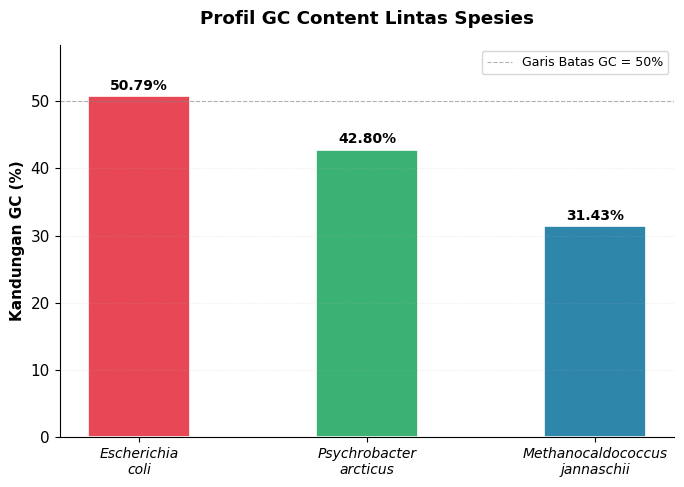

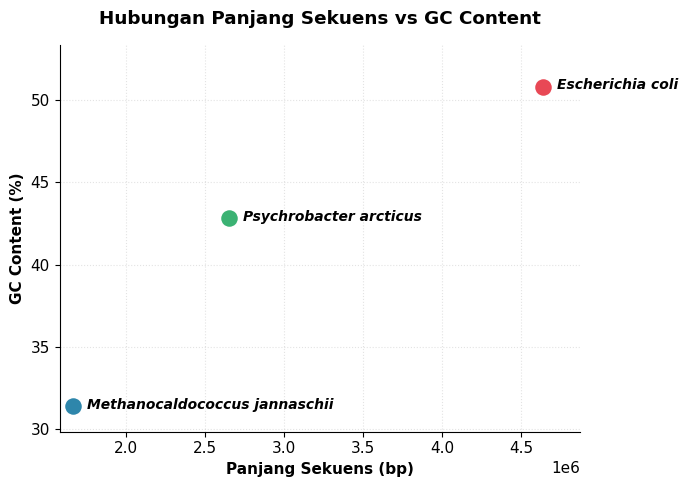

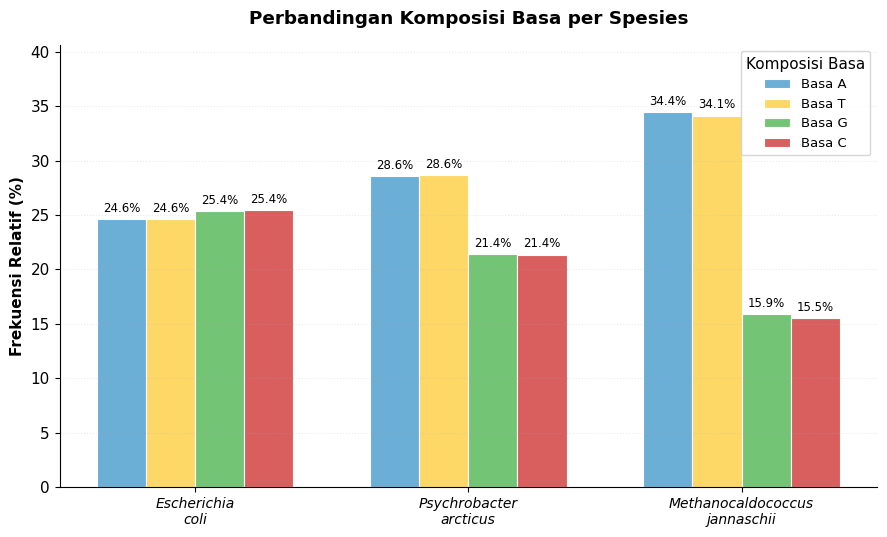

In [6]:
# Visualisasi Terpisah & Resolusi Tinggi (300 DPI)
# Ekstraksi data dari list utama
species_names  = [s['species'] for s in sequence_list_sorted]
gc_values      = [s['gc_content'] for s in sequence_list_sorted]
lengths        = [s['length_bp'] for s in sequence_list_sorted]
bases          = ['A', 'T', 'G', 'C']

# Konfigurasi warna ATGC
# A = Biru Azure, T = Kuning, G = Hijau, C = Merah Carmine
base_colors = {
    'A': '#6BAED6',   # Adenin - Soft Azure Blue
    'T': '#FDD867',   # Timin - Soft Yellow
    'G': '#74C476',   # Guanin - Soft Green
    'C': '#D95F5F'    # Sitosin - Soft Carmine Red
}

colors = [SPECIES_COLOR.get(sp, '#999999') for sp in species_names]

# GRAFIK 1: Bar Chart Kuantitatif GC Content per Spesies
fig1, ax1 = plt.subplots(figsize=(7, 5))

bars = ax1.bar(
    species_names,
    gc_values,
    color=colors,
    width=0.45,
    edgecolor='white',
    linewidth=1.2
)

for bar, val in zip(bars, gc_values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax1.set_title('Profil GC Content Lintas Spesies', fontweight='bold', pad=15)
ax1.set_ylabel('Kandungan GC (%)', fontweight='bold')
ax1.set_ylim(0, max(gc_values) * 1.15)
ax1.set_xticks(range(len(species_names)))
ax1.set_xticklabels(
    [sp.replace(' ', '\n') for sp in species_names],
    fontstyle='italic',
    fontsize=10
)

ax1.axhline(
    50,
    color='gray',
    linestyle='--',
    linewidth=0.8,
    alpha=0.6,
    label='Garis Batas GC = 50%'
)

ax1.legend(fontsize=9, loc='upper right')
ax1.grid(axis='y', linestyle=':', alpha=0.25)

plt.tight_layout()
fig1_path = os.path.join(OUTPUT_DIR, '1_gc_content_per_spesies.png')
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()

# GRAFIK 2: Scatter Plot Panjang Sekuens vs GC Content
fig2, ax2 = plt.subplots(figsize=(7, 5))
for sp, gc, ln in zip(species_names, gc_values, lengths):
    ax2.scatter(
        ln,
        gc,
        color=SPECIES_COLOR.get(sp, '#999999'),
        s=180,
        zorder=5,
        edgecolors='white',
        linewidths=1.5)

    ax2.annotate(
        sp,
        xy=(ln, gc),
        xytext=(10, -2),
        textcoords='offset points',
        fontstyle='italic',
        fontsize=10,
        fontweight='bold')

ax2.set_title('Hubungan Panjang Sekuens vs GC Content', fontweight='bold', pad=15)
ax2.set_xlabel('Panjang Sekuens (bp)', fontweight='bold')
ax2.set_ylabel('GC Content (%)', fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.35, zorder=1)

ax2.set_xlim(min(lengths) * 0.95, max(lengths) * 1.05)
ax2.set_ylim(min(gc_values) * 0.95, max(gc_values) * 1.05)

plt.tight_layout()
fig2_path = os.path.join(OUTPUT_DIR, '2_panjang_vs_gc_content.png')
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()


# GRAFIK 3: Komposisi 4 Basa Nitrogen Dikelompokkan PER SPESIES
fig3, ax3 = plt.subplots(figsize=(9, 5.5))
x_indexes = np.arange(len(species_names))
bar_width = 0.18
for idx, base in enumerate(bases):
    base_values = [seq['freq_percent'][base] for seq in sequence_list_sorted]
    sub_bar_offset = (idx - 1.5) * bar_width

    bars = ax3.bar(
        x_indexes + sub_bar_offset,
        base_values,
        bar_width,
        label=f'Basa {base}',
        color=base_colors[base],
        edgecolor='white',
        linewidth=0.8
    )

    for bar, val in zip(bars, base_values):
        ax3.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8.5
        )

ax3.set_title('Perbandingan Komposisi Basa per Spesies', fontweight='bold', pad=15)
ax3.set_ylabel('Frekuensi Relatif (%)', fontweight='bold')

ax3.set_ylim(
    0,
    max([seq['freq_percent'][b] for seq in sequence_list_sorted for b in bases]) * 1.18)

ax3.set_xticks(x_indexes)
ax3.set_xticklabels(
    [sp.replace(' ', '\n') for sp in species_names],
    fontstyle='italic',
    fontsize=10)

ax3.legend(title='Komposisi Basa', loc='upper right', fontsize=9.5)
ax3.grid(axis='y', linestyle=':', alpha=0.25)

plt.tight_layout()
fig3_path = os.path.join(OUTPUT_DIR, '3_komposisi_basa_per_spesies.png')
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
plt.show()

---
## 7. Membuat DataFrame

In [7]:
# Membuat Tabel Hasil Analisis

df_result = pd.DataFrame([
    {
        "Rank": seq["rank_gc"],
        "Accession ID": seq["id"],
        "Spesies": seq["species"],
        "Panjang Sekuens (bp)": seq["length_bp"],
        "A": seq["freq_count"]["A"],
        "T": seq["freq_count"]["T"],
        "G": seq["freq_count"]["G"],
        "C": seq["freq_count"]["C"],
        "N": seq["freq_count"]["N"],
        "A (%)": seq["freq_percent"]["A"],
        "T (%)": seq["freq_percent"]["T"],
        "G (%)": seq["freq_percent"]["G"],
        "C (%)": seq["freq_percent"]["C"],
        "N (%)": seq["freq_percent"]["N"],
        "GC Content (%)": seq["gc_content"]
    }
    for seq in sequence_list_sorted
])

# Tabel utama untuk laporan
df_main_laporan = df_result[
    ["Rank", "Accession ID", "Spesies", "Panjang Sekuens (bp)", "GC Content (%)"]]

print("📋 Tabel Utama Hasil Analisis GC Content")
display(df_main_laporan)

# Tabel lengkap untuk CSV/lampiran
print("\n📋 Tabel Detail Komposisi Nukleotida")
display(df_result)

📋 Tabel Utama Hasil Analisis GC Content


,Rank,Accession ID,Spesies,Panjang Sekuens (bp),GC Content (%)
0,1,NC_000913.3,Escherichia coli,4641652,50.7907
1,2,NC_007204.1,Psychrobacter arcticus,2650701,42.8002
2,3,NC_000909.1,Methanocaldococcus jannaschii,1664970,31.4265



📋 Tabel Detail Komposisi Nukleotida


,Rank,Accession ID,Spesies,Panjang Sekuens (bp),A,T,G,C,N,A (%),T (%),G (%),C (%),N (%),GC Content (%)
0,1,NC_000913.3,Escherichia coli,4641652,1142742,1141382,1177437,1180091,0,24.62,24.59,25.37,25.42,0.0,50.7907
1,2,NC_007204.1,Psychrobacter arcticus,2650701,757045,759150,568153,566353,0,28.56,28.64,21.43,21.37,0.0,42.8002
2,3,NC_000909.1,Methanocaldococcus jannaschii,1664970,573429,568290,264573,258665,13,34.44,34.13,15.89,15.54,0.0,31.4265


---
## 8. Ekspor Hasil ke CSV


In [8]:
# Export Hasil Analisis ke CSV
# Simpan hasil analisis ke file CSV
df_result.to_csv(OUTPUT_CSV, index=False)

print(f"Hasil analisis berhasil disimpan sebagai '{OUTPUT_CSV}'")

# Download CSV
from google.colab import files
files.download(OUTPUT_CSV)

Hasil analisis berhasil disimpan sebagai 'hasil_gc_content.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>